# Complex Networks Library - a quick guide

This personal library was developed to calculate and analyze network properties easier.

At computational scope, it saves time and energy by looking in a hash-table for pre-calculated dependencies (for instance, other measures) and use them instead of computing all again, as some other libraries will do.

At scientific scope, it stores the values on dataframes, which are easy to manipulate. A lot of database-like operations are implemented, as like some statistical measures. Also, it is compatible with plotting libraries.

We use 2 main entities here: the `GraphAPI` as the data structure to be analyzed, and the `DataPool` as a database for collections of networks and measures, with their results (after being properly calculated).

The first one is an encapsulation of common graph objects. As there is no consense about using `igraph` or `networkx` library, this class allow both of them to be under the sheets, acessed through standarized function calls (for simple uses) of directly by the `data` property (for specific uses). Also, simple graphs can be easily converted from one library to another, also is easy to generate common complex network models.

The last one stores the data in the following dataframes: `networks`, where the graphs and their metadata are stored; `measures`, where the functions and dependences are configurated; and the `results`, that is just a key-value table.

In the data pool tables, some columns may seem to be unnecessary at first glance, as there were included to be used with classification purposes. For example, networks' _collection_, _dataset_ and _label_ properties. It can be ignored here, as we do not aim to classify networks.

Important things to know:

- the "graph" object requested in the measure functions is the `GraphAPI` class; but the graph itself is stored in the `data` property (here we use `igraph` as backbone for efficiency);
- the basic pipeline to use the `DataPool` class from this analytical library is to populate the data pool with the set of networks and measures, and then call the `evaluate(.)` method (possibly defining subsets);
- to summarize the results, the best way is to use the `Report.make(.)` static method, defining a scope of measures (graph-level, node-level, ...) and the measures identifier column;
- as some of the measures are list-like or dict-like, is it possible to request the reporting tool to expand them (explore as new columns).

In [3]:
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd

In [4]:
import sys
sys.path.insert(0, '../src/network_analysis/lib') 
from containers import GraphAPI
from analytics import DataPool, Report
from characterization import Distances, Connectivity, ClusteringAndCycles, Centrality

# How to calculate measures individually

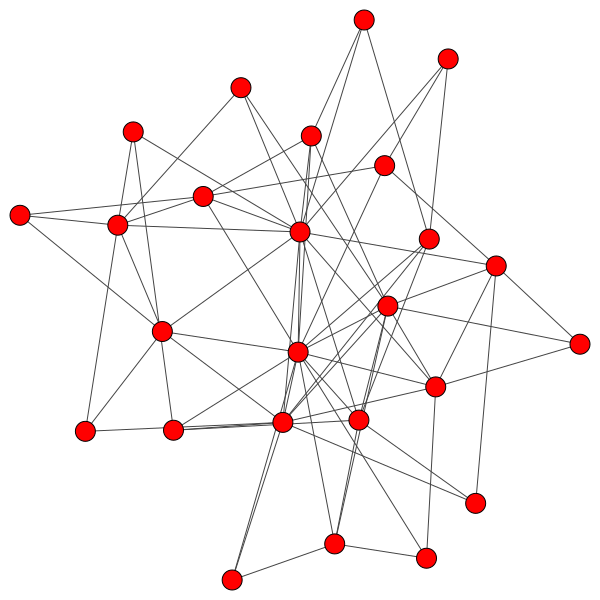

In [64]:
# generating with igraph backbone
G1 = GraphAPI.generate(engine='ig', style='ba', n=25, m=3)
G1.draw()

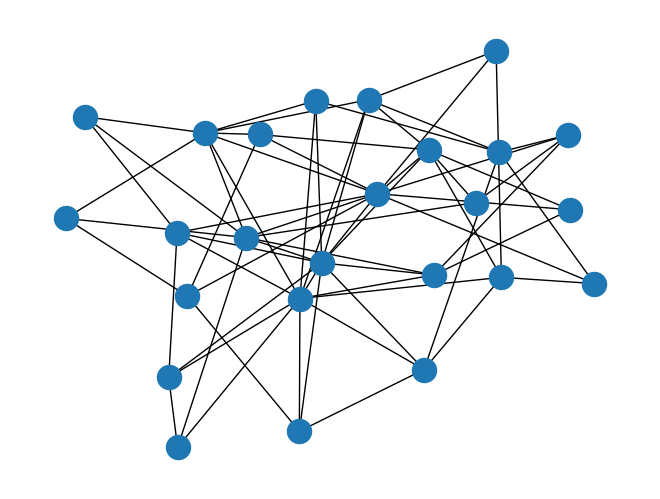

In [65]:
# generating with networkx backbone
G2 = GraphAPI.generate(engine='nx', style='ba', n=25, m=3)
G2.draw()

We can calculate the dependences and pass to the method, but also just call the method itself without nothing besides the graph and it will calculate the dependences inside.

In [72]:
q3 = ClusteringAndCycles.qt_triplets(G1) # node-level
cc = ClusteringAndCycles.vertex_clustering_coeff(G1, q3) # node-level
cc

[0.5274725274725275,
 0.4888888888888889,
 0.9523809523809523,
 0.38461538461538464,
 0.5555555555555556,
 0.5714285714285714,
 0.9333333333333333,
 1.0,
 1.0,
 0.8,
 0.6666666666666666,
 1.3333333333333333,
 1.3333333333333333,
 0.5333333333333333,
 0.6666666666666666,
 1.3333333333333333,
 0.6666666666666666,
 0.4,
 0.6666666666666666,
 0.3333333333333333,
 1.3333333333333333,
 0.0,
 2.0,
 0.6666666666666666,
 0.0]

# How to calculate measures in batch

# Retrieving and analising results

In [5]:
datapool = DataPool()
datapool.load('../data/info', n=True, m=True, r=True)

../data/info/flags.dat loaded in memory
../data/info/networks.dat loaded in memory
../data/info/measures.dat loaded in memory
../data/info/results.dat loaded in memory


In [6]:
datapool.networks

,collection,dataset,label,N,M,K,abbr,graph,source
network_id,,,,,,,,,
0,robustness,toy,BA,100,197,NaN,"BA({'n': 100, 'm': 2})_854227349",<containers.GraphAPI object at 0x7febb867ceb0>,network_000000.txt
1,robustness,toy,BA,100,197,NaN,"BA({'n': 100, 'm': 2})_1078249842",<containers.GraphAPI object at 0x7febb867ce20>,network_000001.txt
2,robustness,toy,BA,100,197,NaN,"BA({'n': 100, 'm': 2})_696283757",<containers.GraphAPI object at 0x7febb867cd90>,network_000002.txt
3,robustness,toy,BA,100,197,NaN,"BA({'n': 100, 'm': 2})_1988659721",<containers.GraphAPI object at 0x7febb867cd00>,network_000003.txt
4,robustness,toy,BA,100,197,NaN,"BA({'n': 100, 'm': 2})_477523455",<containers.GraphAPI object at 0x7febb867cc70>,network_000004.txt
...,...,...,...,...,...,...,...,...,...
145,robustness,toy,BA,100,390,NaN,"BA({'n': 100, 'm': 4})_340565057",<containers.GraphAPI object at 0x7febb834a790>,network_000145.txt
146,robustness,toy,BA,100,390,NaN,"BA({'n': 100, 'm': 4})_936831151",<containers.GraphAPI object at 0x7febb834a820>,network_000146.txt
147,robustness,toy,BA,100,390,NaN,"BA({'n': 100, 'm': 4})_1824413104",<containers.GraphAPI object at 0x7febb834a8b0>,network_000147.txt


In [7]:
datapool.measures

,name,varname,symbol,scope,category,function,dependence,default
measure_id,,,,,,,,
0,shortest distances,min_dist,d_ij,vertex pair,distances,<bound method Distances.shortest_dist of <clas...,None,None
1,shortest distances distribution,p_min_dist,P(d_ij),distrib,distances,<bound method Distances.shortest_dist_distrib ...,[shortest distances],None
2,diameter,diam,D,graph,distances,<bound method Distances.diameter of <class 'ch...,[shortest distances distribution],None
3,average geodesic distance,avg_gdist,l,graph,distances,<bound method Distances.avg_geodesic_dist of <...,[shortest distances distribution],None
4,global efficiency,effic,E,graph,distances,<bound method Distances.global_efficiency of <...,[shortest distances distribution],None
5,harmonic mean of the geodesic distances,hmean_gdist,h,graph,distances,<bound method Distances.hmean_geodesic_dist of...,[global efficiency],None
6,vertex degree,deg,k_i,vertex,connectivity,<bound method Connectivity.vertex_degree of <c...,None,None
7,maximum degree,max_deg,k_max,graph,connectivity,<bound method Connectivity.max_degree of <clas...,[vertex degree],None
8,degree distribution,p_deg,P(k),distrib,connectivity,<bound method Connectivity.deg_distrib of <cla...,[vertex degree],None


In [38]:
m_mask = (datapool.measures['scope']=='graph')
rep_g = Report.make(datapool, measure_subset=m_mask, header='varname', expand=True, detail=False)
rep_g

measures                                  diam avg_gdist     effic  \
dataset abbr                                                         
toy     BA({'n': 100, 'm': 2})_1052861942    6    3.1324  0.353647   
        BA({'n': 100, 'm': 2})_1078249842    6    3.1346  0.353217   
        BA({'n': 100, 'm': 2})_1119879636    5     2.989   0.36658   
        BA({'n': 100, 'm': 2})_1138326505    6    3.0194  0.364713   
        BA({'n': 100, 'm': 2})_1144257784    6    3.0168  0.363597   
...                                        ...       ...       ...   
        BA({'n': 100, 'm': 4})_949213581     4    2.3656  0.457683   
        BA({'n': 100, 'm': 4})_970144785     4     2.324    0.4642   
        BA({'n': 100, 'm': 4})_973800965     4    2.3312  0.462967   
        BA({'n': 100, 'm': 4})_990539191     4     2.334    0.4624   
        BA({'n': 100, 'm': 4})_999466877     4    2.3262     0.464   

measures                                  hmean_gdist max_deg avg_deg  \
dataset abbr                                                            
toy     BA({'n': 100, 'm': 2})_1052861942    2.827681      24    3.94   
        BA({'n': 100, 'm': 2})_1078249842    2.831123      18    3.94   
        BA({'n': 100, 'm': 2})_1119879636    2.727918      29    3.94   
        BA({'n': 100, 'm': 2})_1138326505    2.741879      23    3.94   
        BA({'n': 100, 'm': 2})_1144257784      2.7503      24    3.94   
...                                               ...     ...     ...   
        BA({'n': 100, 'm': 4})_949213581     2.184917      25     7.8   
        BA({'n': 100, 'm': 4})_970144785     2.154244      38     7.8   
        BA({'n': 100, 'm': 4})_973800965     2.159983      32     7.8   
        BA({'n': 100, 'm': 4})_990539191      2.16263      36     7.8   
        BA({'n': 100, 'm': 4})_999466877     2.155172      41     7.8   

measures                                   var_deg     skw_deg      krt_deg  \
dataset abbr                                                                  
toy     BA({'n': 100, 'm': 2})_1052861942  10.7564  120.976368  2043.441977   
        BA({'n': 100, 'm': 2})_1078249842  10.1164   90.321168  1134.138553   
        BA({'n': 100, 'm': 2})_1119879636  13.7364  202.452768  4480.911945   
        BA({'n': 100, 'm': 2})_1138326505  14.2964  169.373568  2729.320841   
        BA({'n': 100, 'm': 2})_1144257784  12.2164  147.639168  2566.069513   
...                                            ...         ...          ...   
        BA({'n': 100, 'm': 4})_949213581      28.9     272.688    4386.7528   
        BA({'n': 100, 'm': 4})_970144785     35.56     558.624   13616.3632   
        BA({'n': 100, 'm': 4})_973800965     34.12      471.12    9912.1456   
        BA({'n': 100, 'm': 4})_990539191     32.58     446.916     9840.492   
        BA({'n': 100, 'm': 4})_999466877     37.36     655.044   17613.9472   

measures                                     avg_cc  avg_bc          cpd  
dataset abbr                                                              
toy     BA({'n': 100, 'm': 2})_1052861942  0.197522  107.12  1403.679773  
        BA({'n': 100, 'm': 2})_1078249842  0.168431  107.23   999.055508  
        BA({'n': 100, 'm': 2})_1119879636  0.286997   99.95  1932.066624  
        BA({'n': 100, 'm': 2})_1138326505  0.282533  101.47  1257.252202  
        BA({'n': 100, 'm': 2})_1144257784  0.212645  101.34  1380.688937  
...                                             ...     ...          ...  
        BA({'n': 100, 'm': 4})_949213581    0.28865   68.78   424.163711  
        BA({'n': 100, 'm': 4})_970144785   0.379938    66.7   961.840626  
        BA({'n': 100, 'm': 4})_973800965   0.421543   67.06   650.710755  
        BA({'n': 100, 'm': 4})_990539191   0.360195    67.2   814.473419  
        BA({'n': 100, 'm': 4})_999466877   0.392956   66.81   955.236713  

[150 rows x 12 columns]

In [9]:
m_mask = (datapool.measures['scope']=='vertex')
rep_v = Report.make(datapool, measure_subset=m_mask, header='varname', expand=True, detail=False)
rep_v

measures                                         deg qt_tri        cc  \
dataset abbr                              vertex                        
toy     BA({'n': 100, 'm': 2})_1052861942 0        3    3.0  0.666667   
                                          1       16  120.0  0.166667   
                                          2       24  276.0  0.115942   
                                          3       11   55.0  0.109091   
                                          4        5   10.0       0.4   
...                                               ..    ...       ...   
        BA({'n': 100, 'm': 4})_999466877  95       4    6.0       0.0   
                                          96       4    6.0  1.333333   
                                          97       4    6.0       0.0   
                                          98       4    6.0  0.666667   
                                          99       4    6.0  0.333333   

measures                                                   bc  
dataset abbr                              vertex               
toy     BA({'n': 100, 'm': 2})_1052861942 0         63.439795  
                                          1        976.646117  
                                          2       1496.762975  
                                          3        589.075983  
                                          4        112.436888  
...                                                       ...  
        BA({'n': 100, 'm': 4})_999466877  95         9.661143  
                                          96         3.939123  
                                          97        14.153986  
                                          98         2.359858  
                                          99          8.26829  

[15000 rows x 4 columns]

In [53]:
rep_g['params'] = list(map(lambda args: args[1].split('_')[0], rep_g.index))
rep_v['params'] = list(map(lambda args: args[1].split('_')[0], rep_v.index))

The measures at graph level visibly changes, but not those at node level.

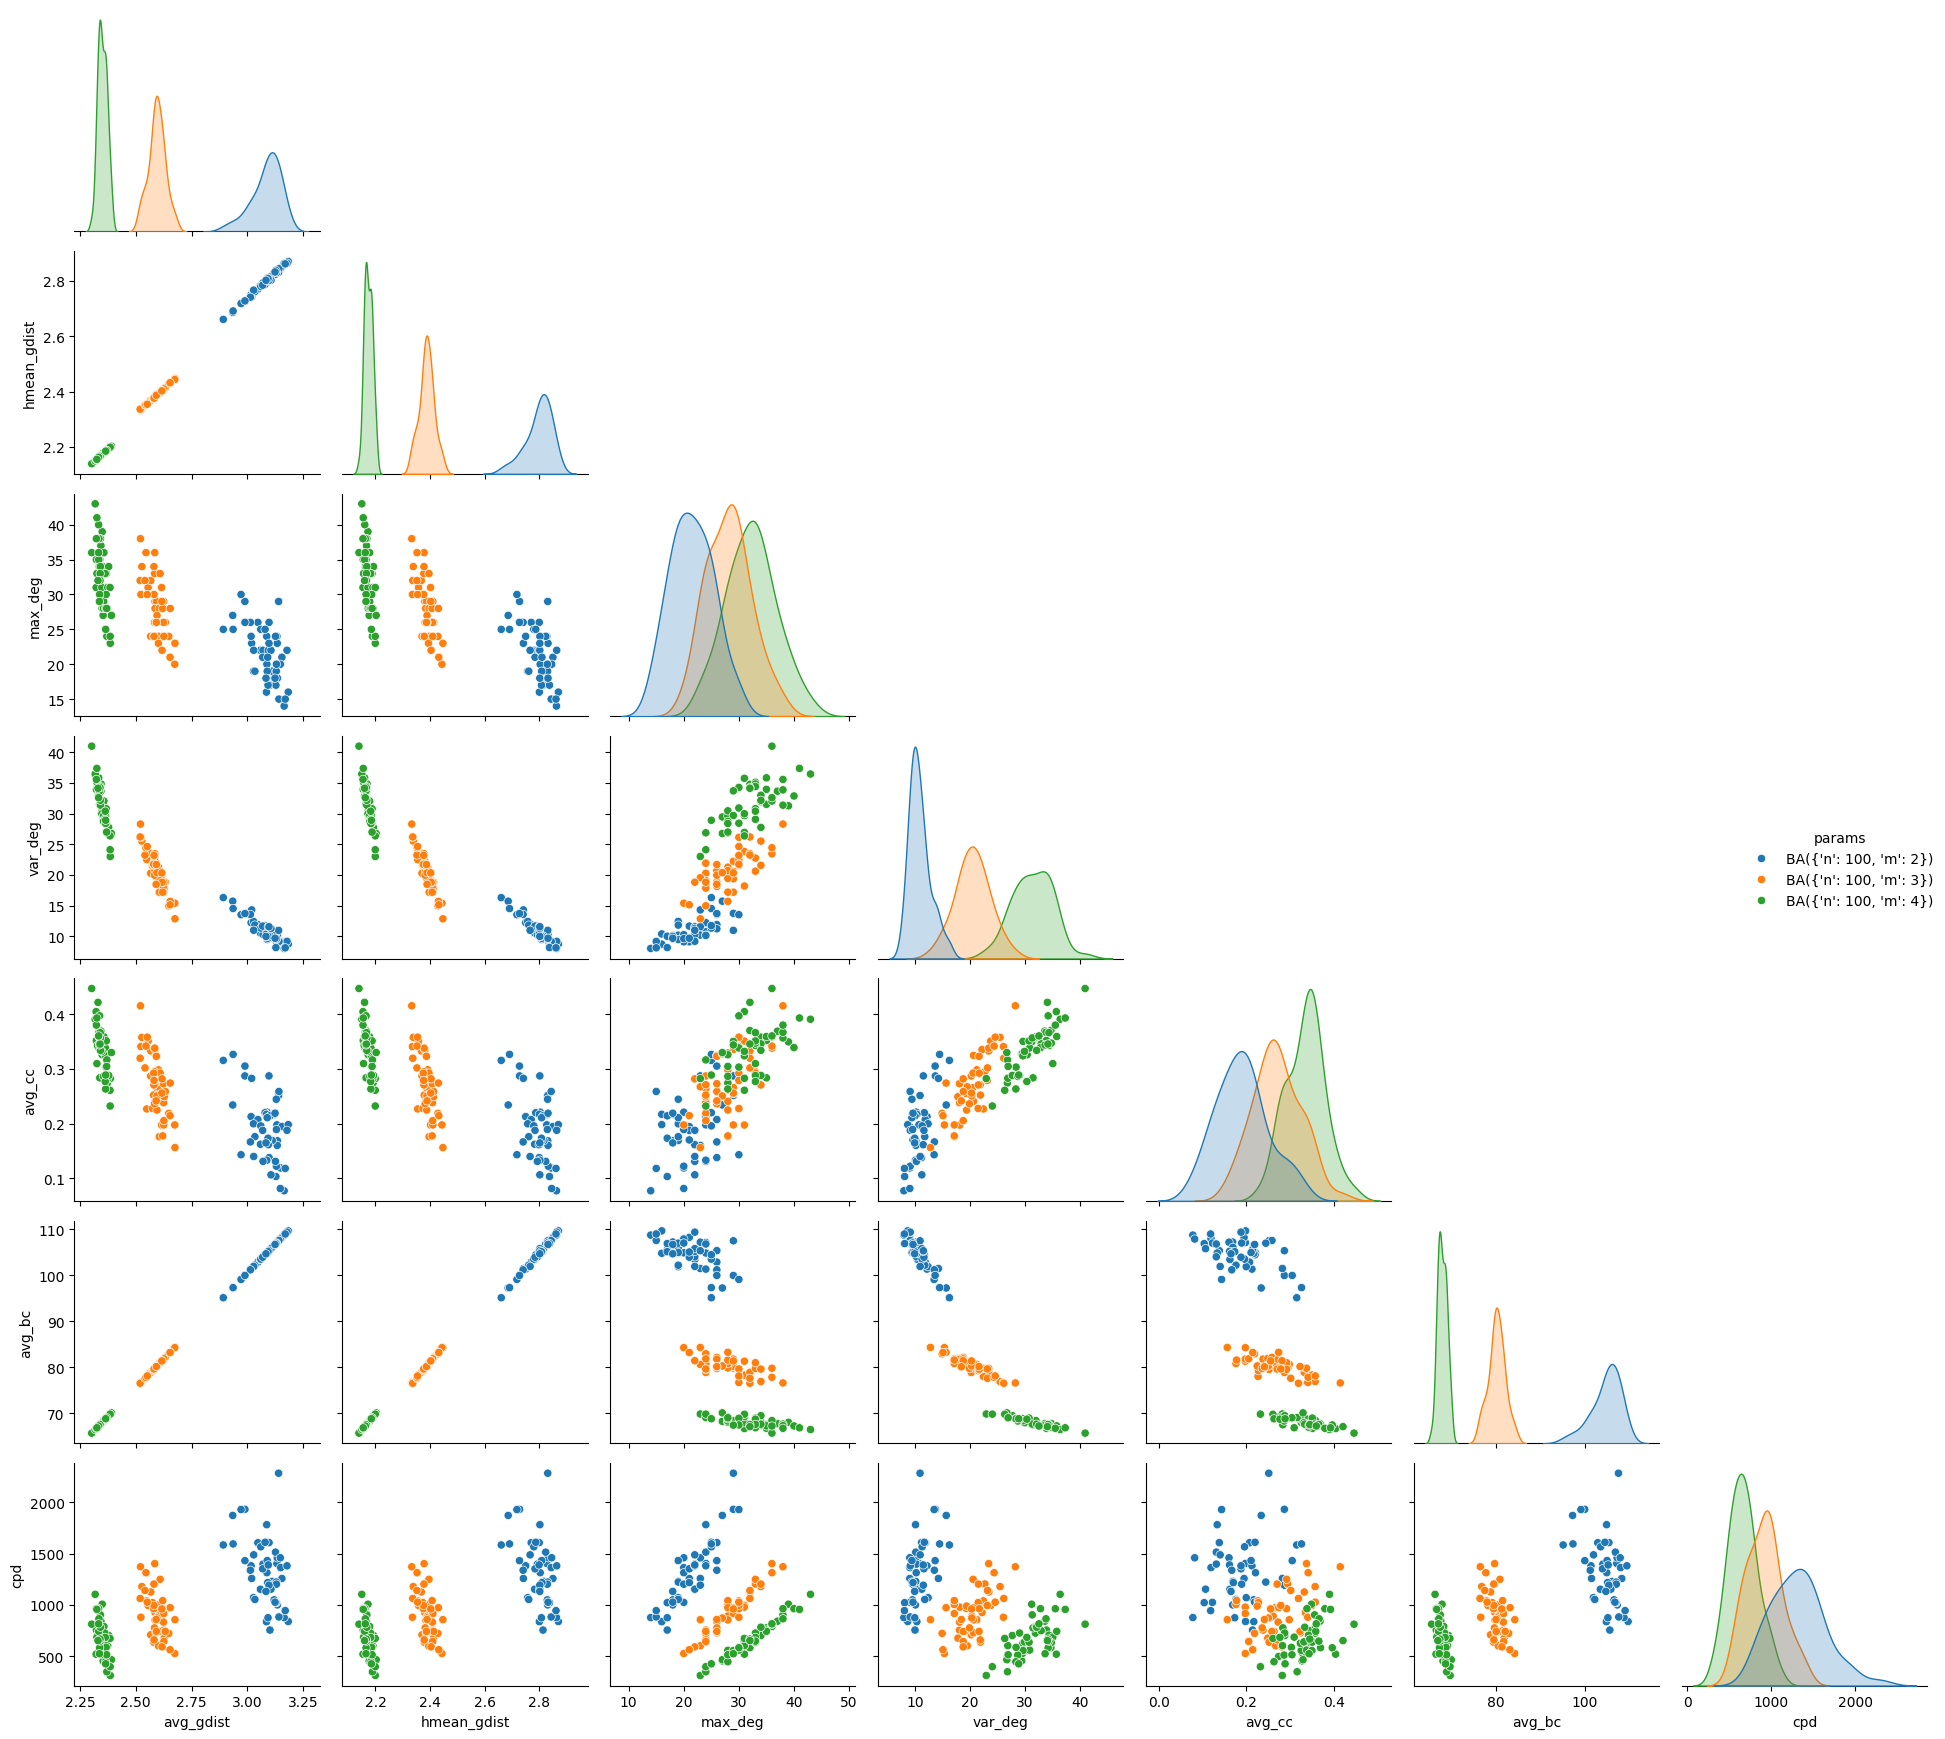

In [54]:
cols_exc = ['diam', 'avg_deg', 'skw_deg', 'krt_deg', 'hmean_gist', 'effic']
cols_inc = [ c for c in rep_g.columns if c not in cols_exc ]
sns.pairplot(
    data = rep_g[cols_inc],
    hue = 'params',
    corner = True,
)
plt.tight_layout()
plt.show()

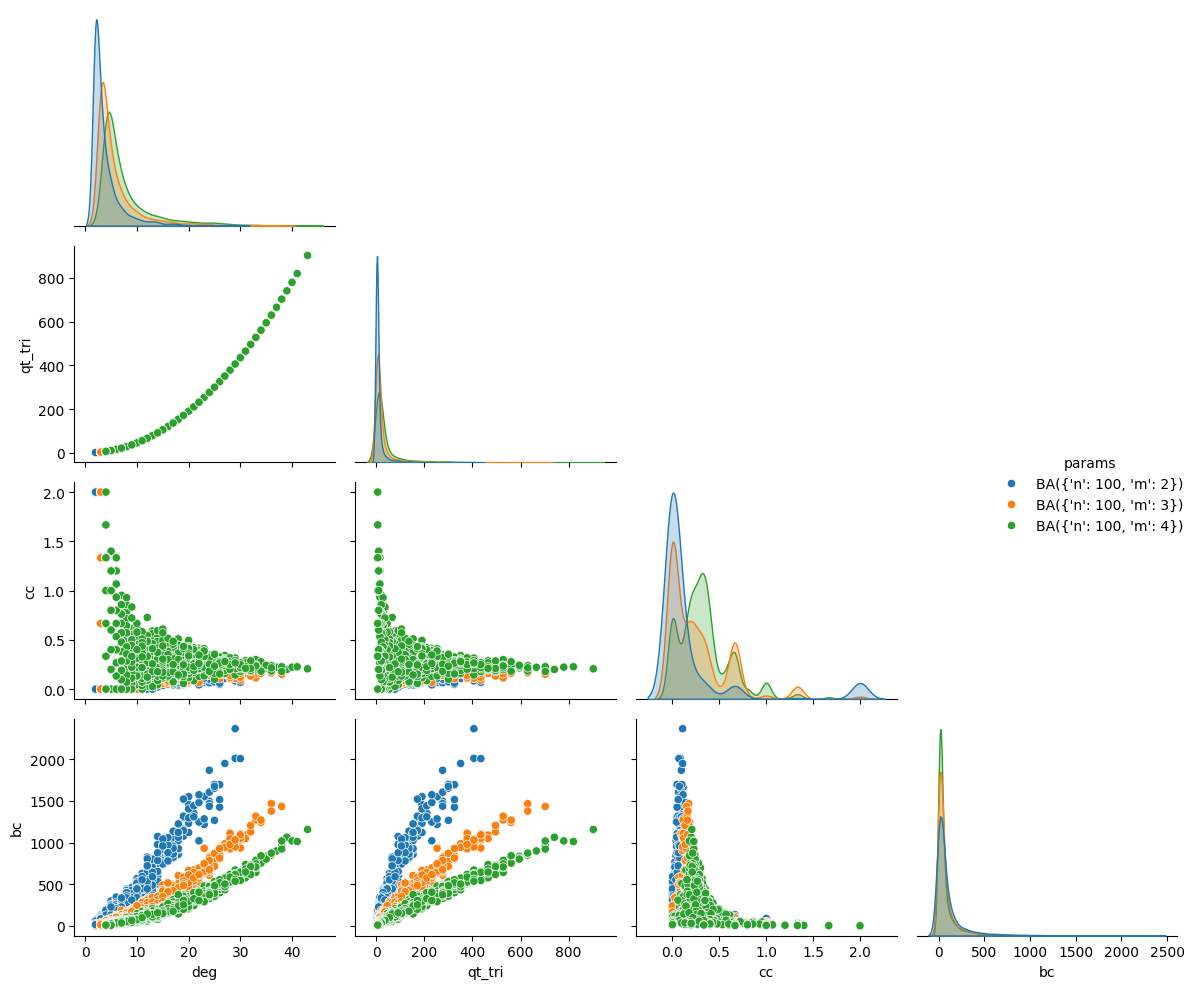

In [58]:
sns.pairplot(
    data = rep_v,
    hue = 'params',
    corner = True,
)
plt.tight_layout()
plt.show()